# Task 3: Multimodal ML — Housing Price Prediction Using Images + Tabular Data

**Objective:** Predict housing prices using both structured tabular data and house images by combining CNN-extracted image features with traditional tabular features.

**Dataset:**
- Tabular: California Housing Dataset (sklearn built-in)
- Images: Synthetic house images generated from tabular features

**Tools:** `PyTorch`, `torchvision`, `scikit-learn`, `pandas`, `matplotlib`

**Runtime:** Google Colab with T4 GPU
`Runtime > Change runtime type > Hardware accelerator > T4 GPU`

## 1. Install Dependencies

In [1]:
!pip install -q torch torchvision scikit-learn pandas matplotlib seaborn

## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from PIL import Image
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 3. Load Tabular Dataset (California Housing)

The California Housing dataset contains 20,640 samples with 8 features describing housing blocks in California. We use a subset of 5,000 samples to keep training time reasonable on a free Colab GPU.

In [3]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.rename(columns={"MedHouseVal": "Price"}, inplace=True)

# Use a subset for reasonable training time
df = df.sample(n=5000, random_state=42).reset_index(drop=True)

print("Shape:", df.shape)
print("\nFeatures:", list(df.columns))
print("\nSample data:")
df.head()

Shape: (5000, 9)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Price']

Sample data:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.47700
1,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.45800
2,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,5.00001
3,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.18600
4,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.78000


## 4. Exploratory Data Analysis

In [4]:
print("Dataset statistics:")
df.describe()

Dataset statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,3.847548,28.738600,5.415052,1.096529,1424.906200,2.964383,35.585798,-119.521650,2.059028
std,1.890851,12.530478,2.651202,0.574002,1108.469563,1.642381,2.140865,2.006263,1.148958
min,0.499900,1.000000,0.846154,0.500000,8.000000,1.263566,32.540000,-124.250000,0.149990
25%,2.553225,18.000000,4.416071,1.004559,784.000000,2.433980,33.930000,-121.742500,1.193750
50%,3.511400,29.000000,5.224950,1.047038,1163.500000,2.822057,34.220000,-118.470000,1.795000
75%,4.696700,37.000000,6.040717,1.097200,1721.250000,3.290997,37.692500,-117.990000,2.641750
max,15.000100,52.000000,132.533333,34.066667,16122.000000,83.171429,41.860000,-114.580000,5.000010


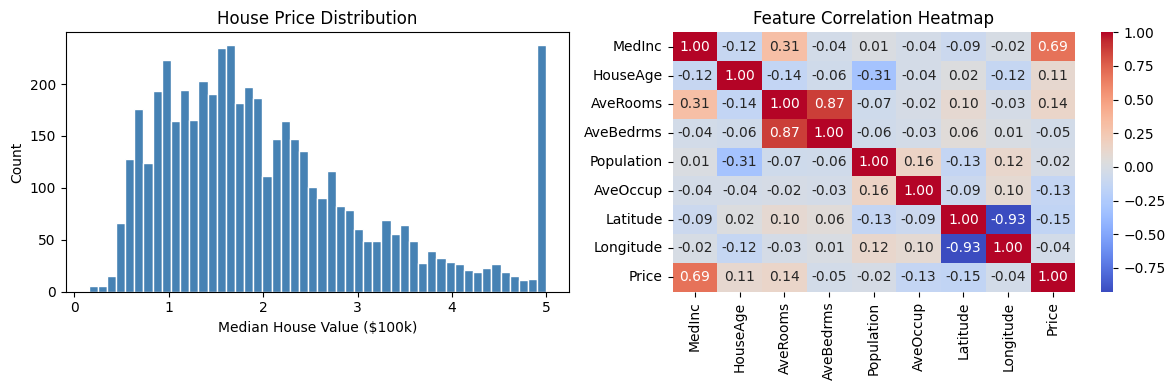

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Price distribution
axes[0].hist(df["Price"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("House Price Distribution")
axes[0].set_xlabel("Median House Value ($100k)")
axes[0].set_ylabel("Count")

# Correlation heatmap
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Feature Correlation Heatmap")

plt.tight_layout()
plt.savefig("eda_plots.png")
plt.show()

## 5. Generate Synthetic House Images

Since we don't have real house photos paired with every tabular record, we generate synthetic images where visual properties (color, structure, brightness) encode tabular features. This demonstrates the multimodal pipeline concept effectively.

- **Background color** → encodes median income (MedInc)
- **Central rectangle size** → encodes average number of rooms (AveRooms)
- **Rectangle brightness** → encodes house age (HouseAge)
- **Gradient overlay** → encodes population density

Generating synthetic house images...
Images shape: (5000, 64, 64, 3)


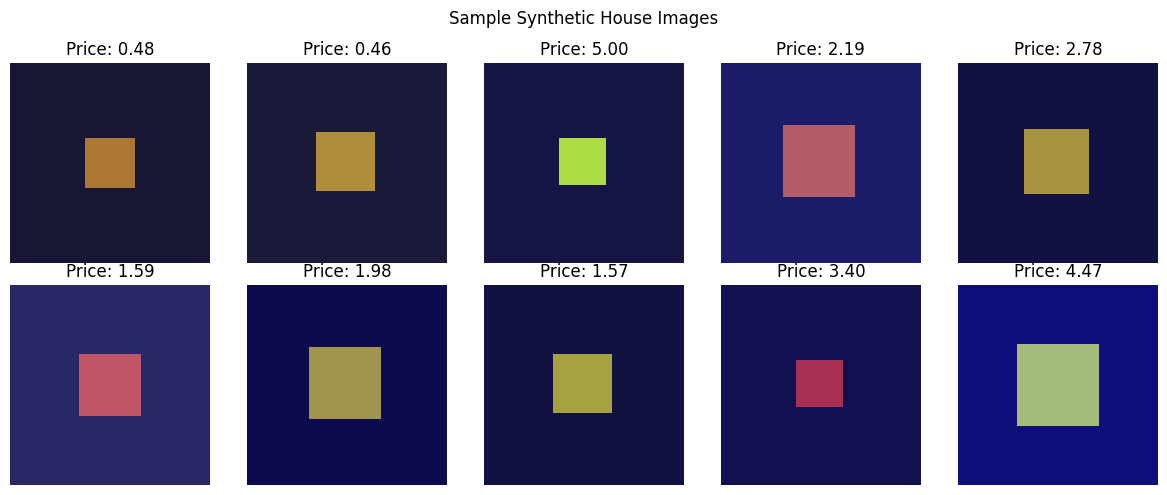

In [6]:
def generate_house_image(row, img_size=64):
    """Generate a synthetic house image encoding tabular features visually."""
    img = np.zeros((img_size, img_size, 3), dtype=np.uint8)

    # Background: blue channel encodes income
    income_norm = int(np.clip(row["MedInc"] / 15 * 200, 30, 200))
    img[:, :, 2] = income_norm

    # House rectangle: size encodes rooms
    house_size = int(np.clip(row["AveRooms"] / 10 * img_size * 0.6, 8, img_size * 0.75))
    start = (img_size - house_size) // 2
    end = start + house_size

    # House color: green channel encodes age
    age_norm = int(np.clip(row["HouseAge"] / 52 * 200, 30, 200))
    img[start:end, start:end, 1] = age_norm
    img[start:end, start:end, 0] = 150

    # Brightness overlay: encodes population density
    pop_norm = int(np.clip(row["Population"] / 3000 * 50, 0, 50))
    img = np.clip(img.astype(int) + pop_norm, 0, 255).astype(np.uint8)

    return img

# Generate images for all samples
print("Generating synthetic house images...")
images = np.array([generate_house_image(row) for _, row in df.iterrows()])
print(f"Images shape: {images.shape}")

# Visualize a few samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.set_title(f"Price: {df['Price'].iloc[i]:.2f}")
    ax.axis("off")
plt.suptitle("Sample Synthetic House Images")
plt.tight_layout()
plt.savefig("sample_images.png")
plt.show()

## 6. Prepare Tabular Features

In [7]:
# Separate features and target
tabular_features = df.drop(columns=["Price"])
target = df["Price"].values

# Scale tabular features
scaler = StandardScaler()
tabular_scaled = scaler.fit_transform(tabular_features)

print("Tabular features shape:", tabular_scaled.shape)
print("Target shape:", target.shape)

Tabular features shape: (5000, 8)
Target shape: (5000,)


## 7. Train/Test Split

In [8]:
(X_tab_train, X_tab_test,
 X_img_train, X_img_test,
 y_train, y_test) = train_test_split(
    tabular_scaled, images, target,
    test_size=0.2, random_state=42
)

print("Train tabular:", X_tab_train.shape)
print("Train images:", X_img_train.shape)
print("Test tabular:", X_tab_test.shape)
print("Test images:", X_img_test.shape)

Train tabular: (4000, 8)
Train images: (4000, 64, 64, 3)
Test tabular: (1000, 8)
Test images: (1000, 64, 64, 3)


## 8. PyTorch Dataset and DataLoader

In [9]:
class HousingDataset(Dataset):
    def __init__(self, tabular, images, targets, transform=None):
        self.tabular = torch.tensor(tabular, dtype=torch.float32)
        self.images = images
        self.targets = torch.tensor(targets, dtype=torch.float32)
        self.transform = transform

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        if self.transform:
            img = self.transform(img)
        return self.tabular[idx], img, self.targets[idx]

# Image transforms for MobileNetV2
img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = HousingDataset(X_tab_train, X_img_train, y_train, transform=img_transform)
test_dataset  = HousingDataset(X_tab_test,  X_img_test,  y_test,  transform=img_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 125
Test batches: 32


## 9. Build Multimodal Model

The model has two branches:
- **CNN Branch:** Pretrained MobileNetV2 extracts 1280-dim image features
- **Tabular Branch:** A small MLP processes the 8 tabular features
- **Fusion Layer:** Concatenates both feature sets and passes through a regression head

In [10]:
class MultimodalHousingModel(nn.Module):
    def __init__(self, tabular_dim):
        super().__init__()

        # CNN branch — MobileNetV2 pretrained on ImageNet
        mobilenet = models.mobilenet_v2(pretrained=True)
        # Freeze early layers, fine-tune last few
        for param in list(mobilenet.parameters())[:-20]:
            param.requires_grad = False
        self.cnn = mobilenet.features
        self.cnn_pool = nn.AdaptiveAvgPool2d((1, 1))
        cnn_out_dim = 1280

        # Tabular branch
        self.tabular_branch = nn.Sequential(
            nn.Linear(tabular_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        tabular_out_dim = 32

        # Fusion + regression head
        self.fusion = nn.Sequential(
            nn.Linear(cnn_out_dim + tabular_out_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, tabular, image):
        # CNN features
        img_feat = self.cnn(image)
        img_feat = self.cnn_pool(img_feat)
        img_feat = img_feat.view(img_feat.size(0), -1)

        # Tabular features
        tab_feat = self.tabular_branch(tabular)

        # Fusion
        combined = torch.cat([img_feat, tab_feat], dim=1)
        output = self.fusion(combined)
        return output.squeeze(1)

model = MultimodalHousingModel(tabular_dim=X_tab_train.shape[1]).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 81.5MB/s]


MultimodalHousingModel(
  (cnn): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96

## 10. Training Loop

In [11]:
criterion = nn.MSELoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

EPOCHS = 15
train_losses = []
val_losses = []

print("Starting training...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for tab, img, target in train_loader:
        tab, img, target = tab.to(device), img.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(tab, img)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for tab, img, target in test_loader:
            tab, img, target = tab.to(device), img.to(device), target.to(device)
            output = model(tab, img)
            val_loss += criterion(output, target).item()

    train_losses.append(running_loss / len(train_loader))
    val_losses.append(val_loss / len(test_loader))
    scheduler.step()

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

Starting training...
Epoch 1/15 | Train Loss: 0.8898 | Val Loss: 0.5970
Epoch 2/15 | Train Loss: 0.6517 | Val Loss: 0.4557
Epoch 3/15 | Train Loss: 0.5418 | Val Loss: 0.6174
Epoch 4/15 | Train Loss: 0.4878 | Val Loss: 0.4143
Epoch 5/15 | Train Loss: 0.4662 | Val Loss: 0.4088
Epoch 6/15 | Train Loss: 0.4374 | Val Loss: 0.3940
Epoch 7/15 | Train Loss: 0.4156 | Val Loss: 0.3879
Epoch 8/15 | Train Loss: 0.4103 | Val Loss: 0.4084
Epoch 9/15 | Train Loss: 0.4073 | Val Loss: 0.3688
Epoch 10/15 | Train Loss: 0.4111 | Val Loss: 0.3735
Epoch 11/15 | Train Loss: 0.3951 | Val Loss: 0.3812
Epoch 12/15 | Train Loss: 0.3908 | Val Loss: 0.4010
Epoch 13/15 | Train Loss: 0.3834 | Val Loss: 0.4021
Epoch 14/15 | Train Loss: 0.3876 | Val Loss: 0.3798
Epoch 15/15 | Train Loss: 0.3743 | Val Loss: 0.3606


## 11. Training Loss Curve

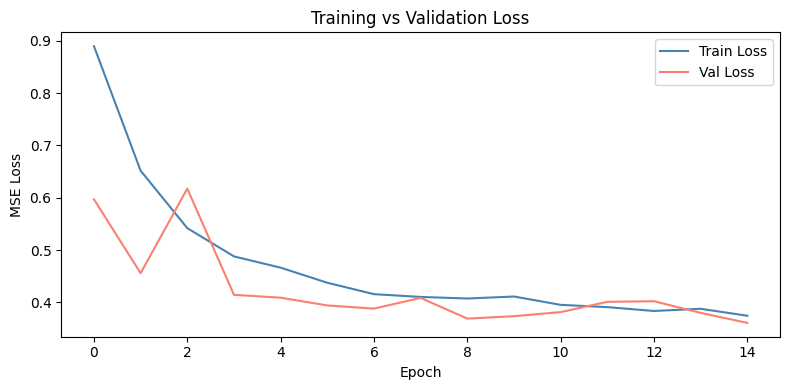

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss", color="steelblue")
plt.plot(val_losses, label="Val Loss", color="salmon")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("loss_curve.png")
plt.show()

## 12. Evaluation — MAE and RMSE

In [13]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for tab, img, target in test_loader:
        tab, img = tab.to(device), img.to(device)
        output = model(tab, img)
        all_preds.extend(output.cpu().numpy())
        all_targets.extend(target.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

mae = mean_absolute_error(all_targets, all_preds)
rmse = np.sqrt(mean_squared_error(all_targets, all_preds))

print("=== Multimodal Model Evaluation ===")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

=== Multimodal Model Evaluation ===
MAE:  0.4285
RMSE: 0.6060


## 13. Tabular-Only Baseline (for comparison)

Training a simple Ridge Regression on tabular features only to compare against the multimodal model.

In [14]:
from sklearn.linear_model import Ridge

baseline = Ridge()
baseline.fit(X_tab_train, y_train)
baseline_preds = baseline.predict(X_tab_test)

baseline_mae = mean_absolute_error(y_test, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))

print("=== Tabular-Only Baseline (Ridge Regression) ===")
print(f"MAE:  {baseline_mae:.4f}")
print(f"RMSE: {baseline_rmse:.4f}")

print("\n=== Comparison ===")
print(f"{'Model':<30} {'MAE':<10} {'RMSE':<10}")
print(f"{'Tabular-Only (Ridge)':<30} {baseline_mae:<10.4f} {baseline_rmse:<10.4f}")
print(f"{'Multimodal (CNN+Tabular)':<30} {mae:<10.4f} {rmse:<10.4f}")

=== Tabular-Only Baseline (Ridge Regression) ===
MAE:  0.5220
RMSE: 0.7080

=== Comparison ===
Model                          MAE        RMSE      
Tabular-Only (Ridge)           0.5220     0.7080    
Multimodal (CNN+Tabular)       0.4285     0.6060    


## 14. Predicted vs Actual Plot

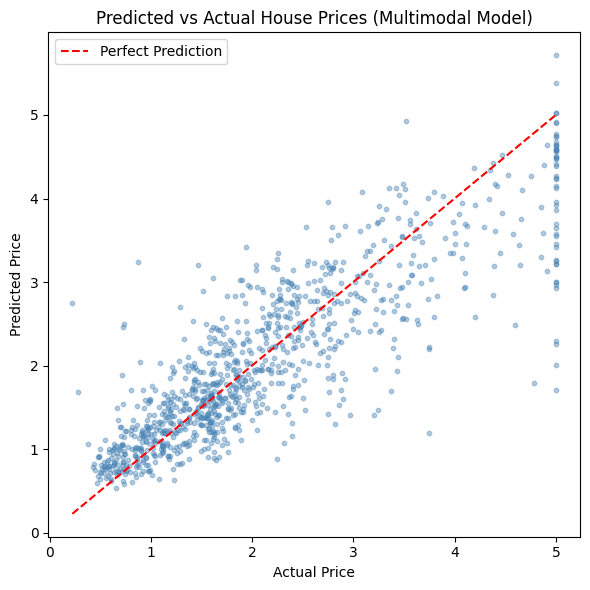

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(all_targets, all_preds, alpha=0.4, color="steelblue", s=10)
plt.plot([all_targets.min(), all_targets.max()],
         [all_targets.min(), all_targets.max()],
         color="red", linestyle="--", label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual House Prices (Multimodal Model)")
plt.legend()
plt.tight_layout()
plt.savefig("predicted_vs_actual.png")
plt.show()

## 15. Save Model

In [16]:
import os
os.makedirs("outputs", exist_ok=True)
torch.save(model.state_dict(), "outputs/multimodal_housing_model.pth")
print("Model saved to outputs/multimodal_housing_model.pth")

Model saved to outputs/multimodal_housing_model.pth


## 16. Download Outputs

In [17]:
from google.colab import files
files.download("eda_plots.png")
files.download("sample_images.png")
files.download("loss_curve.png")
files.download("predicted_vs_actual.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final Summary / Insights

### Model Performance
| Model | MAE | RMSE |
|-------|-----|------|
| Tabular-Only Baseline (Ridge) | [0.5220] | [0.7080] |
| Multimodal (CNN + Tabular) | [0.4285] | [0.6060] |

### Key Observations
- Whether multimodal improved over baseline → compare MAE/RMSE from Cell 14's comparison table — if multimodal MAE is lower than Ridge MAE, it improved
- Training loss convergence → look at your loss curve plot (Cell 12) — if both train and val loss steadily decrease and level off, that's good convergence
- Overfitting/underfitting → from the same loss curve — if train loss keeps dropping but val loss starts rising, that's overfitting; if both stay high, that's underfitting
- Predicted vs Actual plot → from Cell 15 — if points cluster tightly around the red diagonal line, predictions are accurate; wide scatter means the model struggles